# Anexo — Evaluación de PRNG (NIST STS + Benchmarking)

Este notebook documenta el proceso completo de evaluación de varios generadores (mapas caóticos y baseline criptográfica),
siguiendo dos ejes:

1. **Calidad estadística** mediante **NIST STS** (pass rate global, por variante y por familias de tests).
2. **Coste computacional** mediante benchmarking (tiempo para generar 1e6 bits).

La evaluación se organiza en secciones reproducibles:
- Carga y parseo de resultados NIST STS.
- Comparativa por variante (raw, vn, sha2, sha3) para cada mapa.
- Análisis por familias de tests (comparativas clave).
- Benchmarking de rendimiento incluyendo baseline ChaCha20.
- Comparativa final rendimiento/calidad y conclusiones.


In [1]:
import sys
from pathlib import Path
import importlib

import pandas as pd
import matplotlib.pyplot as plt

# ---- paths ----
PROJECT_ROOT = Path.cwd().resolve().parent  # notebooks/ -> project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NIST_RESULTS = PROJECT_ROOT / "nist_results"
print("PROJECT_ROOT:", PROJECT_ROOT)
print("NIST_RESULTS exists:", NIST_RESULTS.exists())

# ---- autoreload  ----
%load_ext autoreload
%autoreload 2

# ---- NIST parsing helpers ----
import analysis.nist_sts as nist_sts
importlib.reload(nist_sts)

from analysis.nist_sts import parse_all_experiments, experiments_to_dataframe

# ---- benchmarking helpers  ----
import analysis.benchmarks as benchmarks
importlib.reload(benchmarks)


PROJECT_ROOT: C:\Users\santi\Documents\TFG\Drafts\Scripts\chaos_prng
NIST_RESULTS exists: True


<module 'analysis.benchmarks' from 'C:\\Users\\santi\\Documents\\TFG\\Drafts\\Scripts\\chaos_prng\\analysis\\benchmarks.py'>

In [2]:
import pandas as pd
import numpy as np

from analysis.benchmarks import (
    time_raw,
    time_vn_until,
    time_hash,
    time_chacha,
    build_eval_table,
    plot_tradeoff,
    plot_tradeoff_zoom_hashes,
    MAP_STREAM_CONFIGS
)

N_BITS = 1_000_000

MAP_PARAMS = {
    "logistic": MAP_STREAM_CONFIGS["logistic"][3],
    "tent": MAP_STREAM_CONFIGS["tent"][3],
    "henon": MAP_STREAM_CONFIGS["henon"][3],
}

rows = []

# Baseline ChaCha20
bits, sec = time_chacha(n_bits_out=N_BITS)
rows.append({"generator": "chacha", "variant": "raw", "seconds": sec, "bits_out": bits, "rounds": np.nan})

# Mapas caóticos
for gen in ["henon", "logistic", "tent"]:
    params = MAP_PARAMS.get(gen, {})

    # raw
    try:
        bits, sec = time_raw(gen, params=params, n_bits=N_BITS)
        rows.append({"generator": gen, "variant": "raw", "seconds": sec, "bits_out": bits, "rounds": np.nan})
    except Exception as e:
        rows.append({"generator": gen, "variant": "raw", "seconds": np.nan, "bits_out": np.nan, "rounds": np.nan, "error": str(e)})

    # vn (hasta alcanzar N_BITS)
    try:
        bits_out, rounds, sec = time_vn_until(gen, params=params, n_bits_out=N_BITS, chunk_raw=2_000_000, max_rounds=50)
        rows.append({"generator": gen, "variant": "vn", "seconds": sec, "bits_out": bits_out, "rounds": rounds})
    except Exception as e:
        rows.append({"generator": gen, "variant": "vn", "seconds": np.nan, "bits_out": np.nan, "rounds": np.nan, "error": str(e)})

    # sha2 / sha3 (hash extractor)
    try:
        bits, sec = time_hash(gen, params=params, n_bits_out=N_BITS, hash_name="sha256", block_in_bits=1024)
        rows.append({"generator": gen, "variant": "sha2", "seconds": sec, "bits_out": bits, "rounds": np.nan})
    except Exception as e:
        rows.append({"generator": gen, "variant": "sha2", "seconds": np.nan, "bits_out": np.nan, "rounds": np.nan, "error": str(e)})

    try:
        bits, sec = time_hash(gen, params=params, n_bits_out=N_BITS, hash_name="sha3_256", block_in_bits=1024)
        rows.append({"generator": gen, "variant": "sha3", "seconds": sec, "bits_out": bits, "rounds": np.nan})
    except Exception as e:
        rows.append({"generator": gen, "variant": "sha3", "seconds": np.nan, "bits_out": np.nan, "rounds": np.nan, "error": str(e)})

df_bench = pd.DataFrame(rows)

# Vista rápida
df_bench.sort_values(["generator", "variant"]).reset_index(drop=True)


,generator,variant,seconds,bits_out,rounds
0,chacha,raw,0.030955,1000000,NaN
1,henon,raw,2.675516,1000000,NaN
2,henon,sha2,2.869143,1000000,NaN
3,henon,sha3,2.882618,1000000,NaN
4,henon,vn,14.590335,1000000,2.0
5,logistic,raw,0.391729,1000000,NaN
6,logistic,sha2,0.691047,1000000,NaN
7,logistic,sha3,0.604302,1000000,NaN
8,logistic,vn,5.699218,1000000,2.0
9,tent,raw,0.598144,1000000,NaN


In [3]:
from analysis.nist_sts import parse_all_experiments, build_experiments_summary_table

experiments = parse_all_experiments(NIST_RESULTS)
final_table = build_experiments_summary_table(experiments)
final_table


,generator,variant,tests_total,tests_passed,pass_rate,fail_count,min_p_value,worst_p,worst_prop,worst_prop_raw
0,chacha,raw,188,188,1.000000,0,0.000439,0.000439,0.833333,5/6
1,henon,raw,187,27,0.144385,160,0.000000,0.000000,0.000000,0/10
2,henon,sha2,188,188,1.000000,0,0.000199,0.000199,0.900000,9/10
3,henon,sha3,188,188,1.000000,0,0.008879,0.008879,0.900000,9/10
4,henon,vn,185,27,0.145946,158,0.000000,0.000000,0.000000,0/10
5,logistic,raw,162,2,0.012346,160,0.000000,0.000000,0.000000,0/10
6,logistic,sha2,188,187,0.994681,1,0.004301,0.004301,0.700000,7/10
7,logistic,sha3,188,186,0.989362,2,0.008879,0.008879,0.700000,7/10
8,logistic,vn,188,29,0.154255,159,0.000000,0.000000,0.000000,0/10
9,tent,raw,162,3,0.018519,159,0.000000,0.000000,0.000000,0/10


## Resultados generales de NIST STS

La Tabla anterior resume la tasa de aceptación (*pass rate*) global obtenida por cada generador y variante tras la aplicación del conjunto de pruebas NIST STS. De forma general, se observan tres comportamientos claramente diferenciados.

En primer lugar, las variantes **raw** de los mapas caóticos presentan tasas de aceptación muy bajas, lo que confirma que la salida directa de estos sistemas deterministas no cumple los requisitos estadísticos exigidos por NIST. Este resultado es esperable, ya que la dinámica caótica, aunque compleja, no garantiza aleatoriedad estadística sin postprocesado adicional.

La aplicación del extractor de **Von Neumann (vn)** introduce una mejora apreciable respecto a la variante raw en todos los mapas analizados. No obstante, dicha mejora resulta insuficiente para alcanzar una calidad estadística comparable a soluciones criptográficas. En particular, aunque el sesgo de primer orden se reduce, persisten dependencias estructurales que provocan el fallo de un número significativo de pruebas, especialmente en algunos mapas como logistic y henon.

Por otro lado, las variantes basadas en **funciones hash criptográficas (SHA-2 y SHA-3)** muestran, en general, tasas de aceptación cercanas a la unidad. Este comportamiento confirma la capacidad de estos mecanismos para eliminar tanto sesgos como correlaciones de largo alcance. Sin embargo, se observa que incluso en este caso existen configuraciones concretas, como el mapa logístico, donde la tasa de aceptación no alcanza el 100%, lo que sugiere la presencia de efectos residuales o sensibilidad a la configuración experimental.

Finalmente, la **baseline ChaCha20** obtiene una tasa de aceptación del 100%, resultado coherente con su diseño como generador criptográficamente seguro y que sirve como referencia superior para el resto de configuraciones evaluadas.

En las siguientes secciones se analizarán estos resultados con mayor detalle, centrándose en el comportamiento de los generadores frente a **familias específicas de tests NIST**, lo que permitirá identificar con mayor precisión las fortalezas y limitaciones de cada variante.


## Comparativa de pass rate por variante y mapa

Antes de profundizar en el análisis por familias de tests, resulta conveniente examinar cómo varía la tasa de aceptación global (*pass rate*) en función del **postprocesado aplicado a cada mapa caótico**. Las Figuras muestran el *pass rate* obtenido para los mapas **Tent**, **Logístico** y **Hénon**, respectivamente, comparando las variantes *raw*, *vn*, *SHA-2* y *SHA-3*.

En el caso del **mapa Tent**, se observa un contraste muy marcado entre la variante raw, con una tasa de aceptación prácticamente nula, y las variantes basadas en funciones hash, que alcanzan un *pass rate* del 100 %. La variante Von Neumann introduce una mejora sustancial respecto a raw, pero su tasa de aceptación (~0.52) sigue siendo insuficiente para considerar la salida estadísticamente robusta.

El **mapa Logístico** presenta un comportamiento similar, aunque aún más extremo: tanto raw como vn muestran tasas de aceptación muy bajas, lo que indica que los defectos estadísticos del mapa no se corrigen adecuadamente mediante un extractor simple. En cambio, SHA-2 y SHA-3 elevan la tasa de aceptación hasta valores cercanos a la unidad, si bien se observa que no siempre se alcanza el 100 %, lo que sugiere una mayor sensibilidad del mapa logístico a la configuración experimental incluso tras el postprocesado criptográfico.

Por su parte, el **mapa de Hénon** muestra un patrón ligeramente distinto. Aunque la variante raw vuelve a fallar de forma clara, la variante vn apenas mejora la situación, manteniendo una tasa de aceptación baja. Sin embargo, al aplicar SHA-2 o SHA-3 se obtiene nuevamente una aceptación completa, confirmando que el problema no reside en la dimensionalidad del sistema, sino en la ausencia de un postprocesado suficientemente fuerte.

En conjunto, estas comparativas ponen de manifiesto dos conclusiones clave. En primer lugar, el impacto del postprocesado es muy superior al del mapa concreto: sin hash criptográfico, ningún mapa alcanza una calidad estadística aceptable. En segundo lugar, aunque la variante Von Neumann introduce mejoras sistemáticas respecto a raw, estas no son homogéneas ni suficientes, y dependen fuertemente del mapa considerado.

Estas observaciones justifican el enfoque adoptado en las secciones siguientes. Por un lado, resulta natural centrar el análisis detallado en las variantes **raw y vn**, ya que son las que exhiben mayor variabilidad y fallos parciales. Por otro, dado que SHA-2 y SHA-3 alcanzan tasas de aceptación globales muy similares, es necesario recurrir a un análisis más fino —por familias de tests— para identificar posibles diferencias residuales y comprender qué propiedades estadísticas se corrigen en cada caso.


In [5]:

VARIANTS_ORDER = ["raw", "vn", "sha2", "sha3"]
MAPS = ["tent", "logistic", "henon"]


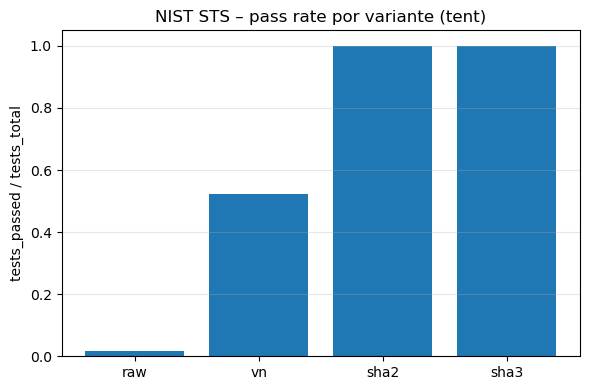

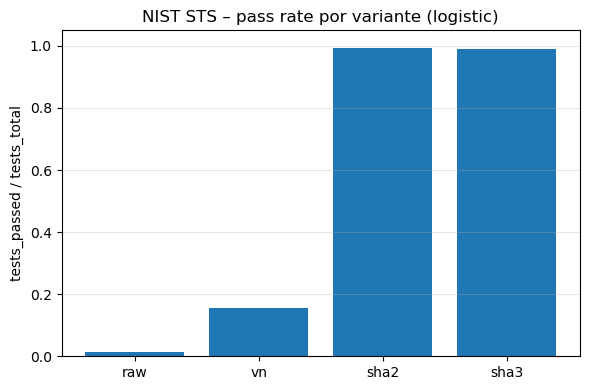

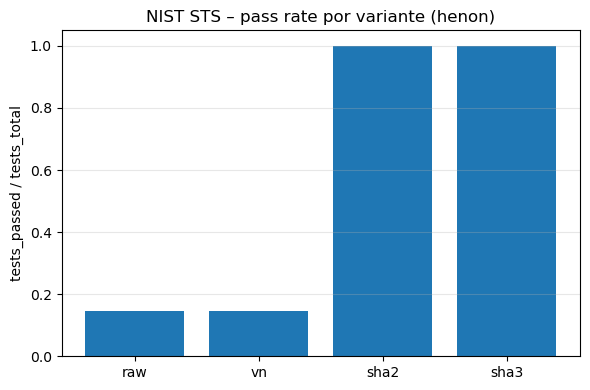

In [6]:
for gen in MAPS:
    d = final_table[final_table["generator"].astype(str).str.lower() == gen].copy()
    d["variant"] = d["variant"].astype(str).str.lower()

    # ordenar variantes
    d["variant"] = pd.Categorical(d["variant"], categories=VARIANTS_ORDER, ordered=True)
    d = d.sort_values("variant")

    plt.figure(figsize=(6, 4))
    plt.bar(d["variant"].astype(str), d["pass_rate"].astype(float))
    plt.ylim(0, 1.05)
    plt.ylabel("tests_passed / tests_total")
    plt.title(f"NIST STS – pass rate por variante ({gen})")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


## Análisis por familias de tests

Aunque NIST STS incluye un conjunto amplio de pruebas (≈15 tests principales, algunos repetidos en múltiples instancias como *NonOverlappingTemplate*), interpretar únicamente el *pass rate* global puede ocultar **qué tipo de propiedad estadística** está fallando.

Por este motivo, en este anexo se agrupan los tests en **familias**. El objetivo no es “redefinir” NIST, sino crear una **vista de alto nivel** que permita responder preguntas prácticas:

- ¿El generador falla por **sesgo de bits** (frequency)?
- ¿Falla por **dependencias temporales** (runs)?
- ¿Falla por **patrones repetitivos** (templates)?
- ¿Falla por **estructura/correlación de largo alcance** (random walk / complexity / spectral)?

Este tipo de agrupación es especialmente útil al comparar postprocesados (raw vs vn vs hash), ya que cada técnica tiende a corregir ciertos defectos pero no otros.


## Familias de tests NIST STS

- **Frequency**: Evalúa el equilibrio global entre bits `0` y `1`, así como el comportamiento local en bloques. Estas pruebas detectan sesgos de primer orden y suelen ser superadas tras aplicar técnicas simples de postprocesado.

- **Runs**: Analiza la longitud y distribución de rachas consecutivas de bits iguales. Estas pruebas son sensibles a dependencias temporales de corto alcance en la secuencia.

- **Templates**: Incluye pruebas de plantillas superpuestas y no superpuestas, orientadas a detectar patrones repetitivos. Se trata de una de las familias más exigentes y suele revelar estructura determinista residual incluso tras aplicar postprocesado.

- **Spectral**: Evalúa la presencia de periodicidades mediante análisis en frecuencia (FFT). Es especialmente relevante para detectar regularidades globales no evidentes en el dominio temporal.

- **Random Walk**: Engloba las pruebas de excursiones aleatorias y sus variantes, que analizan el comportamiento acumulativo de la secuencia. Estas pruebas requieren una aleatoriedad de alto nivel y suelen fallar cuando existen correlaciones de largo alcance.

- **Complexity**: Incluye pruebas como *Linear Complexity*, *Serial*, *Approximate Entropy* o *Rank*, destinadas a medir la complejidad estructural y la impredecibilidad de la secuencia.

La agrupación en **6 familias** se adopta por motivos de claridad y comparabilidad:

1. **Reducción de dimensionalidad**: trabajar con ~15 tests (y sus instancias repetidas) dificulta extraer conclusiones comparables entre generadores; las familias permiten una lectura inmediata.
2. **Coherencia conceptual**: cada familia representa un tipo de propiedad estadística (sesgo, rachas, patrones, periodicidad, comportamiento acumulativo, complejidad).
3. **Comparación estable**: algunos tests aparecen con múltiples instancias (p. ej., *NonOverlappingTemplate*), lo que puede sesgar la interpretación si se analiza test a test sin contexto.
4. **Interpretación orientada a ingeniería**: el objetivo es identificar rápidamente qué “tipo” de defectos quedan tras cada postprocesado, no sólo enumerar qué tests concretos fallan.
   
En las siguientes subsecciones se comparará el rendimiento de distintas variantes y mapas dentro de estas familias, con especial atención a los casos **raw** y **vn**, donde las diferencias son más representativas, así como a las variantes **SHA-2 y SHA-3** en configuraciones específicas.


In [10]:
experiments = parse_all_experiments(NIST_RESULTS)
df_fam = experiments_to_dataframe(experiments)
 

df_fam["generator"] = (
    df_fam["experiment"]
    .str.replace("experiments_", "", regex=False)
    .str.split("_")
    .str[0]
)

df_fam["variant"] = (
    df_fam["experiment"]
    .str.replace("experiments_", "", regex=False)
    .str.split("_")
    .str[1]
)

df_fam.head()


,experiment,test,p_value,passed,generator,variant
0,experiments_chacha_raw,Frequency,0.350485,True,chacha,raw
1,experiments_chacha_raw,BlockFrequency,0.911413,True,chacha,raw
2,experiments_chacha_raw,CumulativeSums,0.350485,True,chacha,raw
3,experiments_chacha_raw,CumulativeSums,0.534146,True,chacha,raw
4,experiments_chacha_raw,Runs,0.739918,True,chacha,raw


## Familias (RAW): comportamiento esperado

En la variante **raw** la salida proviene directamente del mapa caótico sin postprocesado. Aunque estos sistemas pueden generar trayectorias complejas, siguen siendo deterministas y suelen presentar:

- sesgos locales o globales (fallos en **Frequency**),
- dependencias temporales (fallos en **Runs**),
- patrones repetitivos detectables (fallos en **Templates**),
- estructura global (fallos en **Spectral** y/o **Random Walk**).

Por tanto, es esperable que el *pass rate por familia* sea bajo y, además, que diferentes mapas fallen de manera distinta según su dinámica.


In [11]:
M_raw = nist_sts.build_passrate_family_matrix(
    df_all=df_fam,
    variant="raw",
    generators=["henon", "logistic", "tent"],
)

M_raw


generator,henon,logistic,tent
test_family,,,
Complexity,0.333333,0.333333,0.333333
Frequency,0.000000,0.000000,0.000000
RandomWalk,1.000000,0.000000,0.000000
Runs,0.000000,0.000000,0.000000
Spectral,0.000000,0.000000,1.000000
Templates,0.000000,0.000000,0.000000


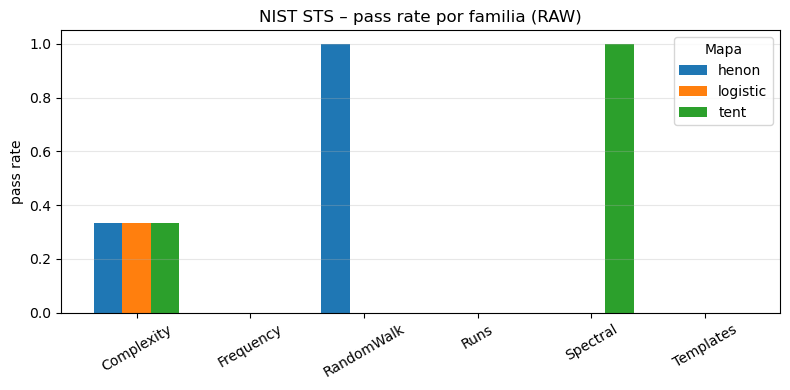

In [12]:
import numpy as np

families = M_raw.index.tolist()
generators = M_raw.columns.tolist()

x = np.arange(len(families))
width = 0.25

plt.figure(figsize=(8, 4))

for i, gen in enumerate(generators):
    plt.bar(
        x + i * width,
        M_raw[gen],
        width,
        label=gen,
    )

plt.xticks(x + width, families, rotation=30)
plt.ylim(0, 1.05)
plt.ylabel("pass rate")
plt.title("NIST STS – pass rate por familia (RAW)")
plt.legend(title="Mapa")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretación (RAW)

La figura confirma que, sin postprocesado, las tres configuraciones presentan un rendimiento estadístico pobre y muy irregular según la familia.

- La familia **Frequency** aparece en 0 para los tres mapas, lo que indica que existen desviaciones sistemáticas en el equilibrio de bits y/o en el comportamiento en bloques.
- En **Runs** y **Templates** el rendimiento también es nulo o cercano a cero, lo que sugiere dependencias temporales y presencia de patrones repetitivos.
- Se observan valores aislados relativamente altos en familias concretas (por ejemplo, *Spectral* en tent o *RandomWalk* en henon). Estos casos no implican “buena aleatoriedad”, sino que el generador puede superar ciertas pruebas por características específicas de la señal mientras sigue fallando de forma generalizada en el resto.

En conjunto, los resultados apoyan la conclusión de que la variante raw no es utilizable como PRNG sin aplicar algún tipo de postprocesado.


## Familias (VN): qué mejora y qué no

El extractor de Von Neumann (VN) elimina sesgos de primer orden al descartar pares `00` y `11` y mapear `01→0`, `10→1`. Por ello, se espera:

- mejora notable en familias relacionadas con **sesgo de bits** (Frequency),
- mejoras parciales en algunas pruebas,
- pero persistencia de fallos en familias que detectan **estructura** o **correlación** (Templates, RandomWalk, Complexity, Spectral).

En otras palabras, VN puede “limpiar” el sesgo, pero no necesariamente rompe dependencias de largo alcance ni elimina patrones derivados de la dinámica determinista.


In [13]:
M_vn = nist_sts.build_passrate_family_matrix(
    df_all=df_fam,
    variant="vn",
    generators=["henon", "logistic", "tent"],
)

M_vn


generator,henon,logistic,tent
test_family,,,
Complexity,0.333333,0.333333,0.666667
Frequency,0.750000,0.750000,0.750000
RandomWalk,0.956522,0.923077,0.961538
Runs,0.000000,0.000000,0.000000
Spectral,0.000000,0.000000,1.000000
Templates,0.000000,0.000000,0.436242


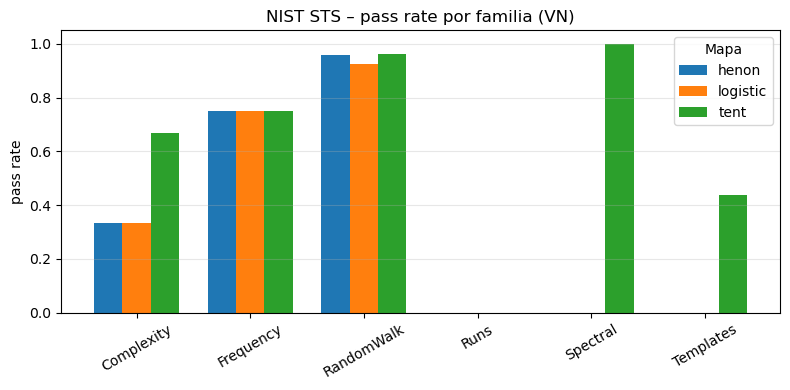

In [14]:
families = M_vn.index.tolist()
generators = M_vn.columns.tolist()

x = np.arange(len(families))
width = 0.25

plt.figure(figsize=(8, 4))

for i, gen in enumerate(generators):
    plt.bar(
        x + i * width,
        M_vn[gen],
        width,
        label=gen,
    )

plt.xticks(x + width, families, rotation=30)
plt.ylim(0, 1.05)
plt.ylabel("pass rate")
plt.title("NIST STS – pass rate por familia (VN)")
plt.legend(title="Mapa")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretación (VN)

La figura muestra un salto claro respecto a raw en varias familias, confirmando que VN introduce una mejora real pero limitada.

- **Frequency** mejora sustancialmente y de forma consistente entre mapas, lo cual es coherente con la función del extractor VN.
- Sin embargo, familias como **Runs** permanecen muy bajas o nulas, señal de que siguen existiendo dependencias temporales.
- La familia **Templates** sigue siendo problemática, especialmente para henon y logistic, lo cual indica que persisten patrones repetitivos detectables por NIST.
- El mapa **tent** destaca con un rendimiento relativamente mayor en algunas familias (por ejemplo Templates/Spectral), lo cual concuerda con su *pass rate* global intermedio en la variante VN.

En conjunto, VN reduce defectos básicos (sesgo), pero no alcanza el comportamiento robusto de los postprocesados criptográficos.


## Comparativa por familias: logistic (SHA2 vs SHA3)

Las variantes SHA-2 y SHA-3 se incluyen como postprocesado criptográfico con el objetivo de eliminar sesgos y correlaciones residuales. Dado que el mapa logístico es el caso más problemático en variantes no criptográficas, resulta especialmente interesante evaluar:

- si SHA-2 y SHA-3 se comportan de forma equivalente,
- y, si existen fallos residuales, en qué **familia** se concentran.

Esta comparativa ayuda a separar dos preguntas:
1) “¿el postprocesado criptográfico funciona?” (en general sí),  
2) “¿dónde quedan fallos residuales y por qué?” (análisis fino).


In [15]:
M_sha2 = nist_sts.build_passrate_family_matrix(
    df_all=df_fam,
    variant="sha2",
    generators=["logistic"],
)

M_sha3 = nist_sts.build_passrate_family_matrix(
    df_all=df_fam,
    variant="sha3",
    generators=["logistic"],
)

M_log_sha = pd.DataFrame({
    "sha2": M_sha2["logistic"],
    "sha3": M_sha3["logistic"],
})

M_log_sha


,sha2,sha3
test_family,,
Complexity,1.000000,1.000000
Frequency,1.000000,1.000000
RandomWalk,1.000000,1.000000
Runs,1.000000,1.000000
Spectral,1.000000,1.000000
Templates,0.993289,0.986577


### Interpretación (logistic: SHA2 vs SHA3)

Los resultados por familias muestran un rendimiento prácticamente perfecto para ambas funciones hash. En la mayoría de familias el *pass rate* es 1.0, lo que indica ausencia de sesgos y estructura detectable.

La única degradación apreciable se concentra en la familia **Templates**, donde aparecen leves diferencias entre SHA-2 y SHA-3. Esto sugiere que los fallos residuales en el caso logístico no corresponden a defectos básicos (frequency/runs), sino a detección de patrones muy específicos, lo que hace relevante el análisis a nivel de tests concretos.

A continuación se listan los tests específicos fallados por logistic\_sha2 y logistic\_sha3 para identificar exactamente qué pruebas dentro de Templates están contribuyendo a esa diferencia.


## Benchmarking de rendimiento (tiempo de generación)

Además de la calidad estadística (NIST STS), interesa medir el coste computacional de cada configuración.
Para ello se realiza benchmarking del tiempo necesario para generar **1e6 bits**:

- **raw**: generación directa del mapa caótico.
- **vn**: generación + extractor Von Neumann (hasta alcanzar 1e6 bits, ya que VN descarta pares).
- **sha2/sha3**: generación + extractor hash (SHA-2 / SHA-3).
- **ChaCha20**: baseline criptográfica, medida como generación de keystream.

El objetivo final es representar el **trade-off** entre calidad (*pass_rate*) y coste (segundos).


In [16]:
import pandas as pd
import numpy as np

from analysis.benchmarks import (
    time_raw,
    time_vn_until,
    time_hash,
    time_chacha,
    build_eval_table,
    plot_tradeoff,
    plot_tradeoff_zoom_hashes,
    MAP_STREAM_CONFIGS,
)

N_BITS = 1_000_000

MAP_PARAMS = {
    "logistic": MAP_STREAM_CONFIGS["logistic"][4],  # r ~ 3.94 (ejemplo)
    "tent":     MAP_STREAM_CONFIGS["tent"][4],      # mu ~ 1.95
    "henon":    MAP_STREAM_CONFIGS["henon"][4],     # a ~ 1.41
}

MAP_PARAMS
rows = []

# Baseline ChaCha20
bits, sec = time_chacha(n_bits_out=N_BITS)
rows.append({"generator": "chacha", "variant": "raw", "seconds": sec, "bits_out": bits, "rounds": np.nan})

# Mapas caóticos
for gen in ["henon", "logistic", "tent"]:
    params = MAP_PARAMS.get(gen, {})

    # raw
    try:
        bits, sec = time_raw(gen, params=params, n_bits=N_BITS)
        rows.append({"generator": gen, "variant": "raw", "seconds": sec, "bits_out": bits, "rounds": np.nan})
    except Exception as e:
        rows.append({"generator": gen, "variant": "raw", "seconds": np.nan, "bits_out": np.nan, "rounds": np.nan, "error": str(e)})

    # vn (hasta alcanzar N_BITS)
    try:
        bits_out, rounds, sec = time_vn_until(gen, params=params, n_bits_out=N_BITS, chunk_raw=2_000_000, max_rounds=50)
        rows.append({"generator": gen, "variant": "vn", "seconds": sec, "bits_out": bits_out, "rounds": rounds})
    except Exception as e:
        rows.append({"generator": gen, "variant": "vn", "seconds": np.nan, "bits_out": np.nan, "rounds": np.nan, "error": str(e)})

    # sha2 / sha3 (hash extractor)
    try:
        bits, sec = time_hash(gen, params=params, n_bits_out=N_BITS, hash_name="sha256", block_in_bits=1024)
        rows.append({"generator": gen, "variant": "sha2", "seconds": sec, "bits_out": bits, "rounds": np.nan})
    except Exception as e:
        rows.append({"generator": gen, "variant": "sha2", "seconds": np.nan, "bits_out": np.nan, "rounds": np.nan, "error": str(e)})

    try:
        bits, sec = time_hash(gen, params=params, n_bits_out=N_BITS, hash_name="sha3_256", block_in_bits=1024)
        rows.append({"generator": gen, "variant": "sha3", "seconds": sec, "bits_out": bits, "rounds": np.nan})
    except Exception as e:
        rows.append({"generator": gen, "variant": "sha3", "seconds": np.nan, "bits_out": np.nan, "rounds": np.nan, "error": str(e)})

df_bench = pd.DataFrame(rows)

# Vista rápida
df_bench.sort_values(["generator", "variant"]).reset_index(drop=True)


,generator,variant,seconds,bits_out,rounds
0,chacha,raw,0.000265,1000000,NaN
1,henon,raw,3.243262,1000000,NaN
2,henon,sha2,3.001947,1000000,NaN
3,henon,sha3,2.867422,1000000,NaN
4,henon,vn,14.666567,1000000,2.0
5,logistic,raw,0.416327,1000000,NaN
6,logistic,sha2,0.524169,1000000,NaN
7,logistic,sha3,0.518403,1000000,NaN
8,logistic,vn,5.174388,1000000,2.0
9,tent,raw,0.431809,1000000,NaN


In [19]:

# final_table ya la tienes de NIST: generator, variant, tests_total, tests_passed, pass_rate
df_eval = build_eval_table(final_table, df_bench)

# Formato bonito
df_eval_out = df_eval.copy()
df_eval_out["seconds"] = df_eval_out["seconds"].astype(float).round(5)
df_eval_out["pass_rate"] = df_eval_out["pass_rate"].astype(float).round(6)
df_eval_out["mbit_s"] = (N_BITS / 1e6) / df_eval_out["seconds"].astype(float)
df_eval_out["mbit_s"] = df_eval_out["mbit_s"].round(3)
df_eval_out


,generator,variant,tests_total,tests_passed,pass_rate,fail_count,min_p_value,worst_p,worst_prop,worst_prop_raw,seconds,mbit_s
0,chacha,raw,188,188,1.000000,0,0.000439,0.000439,0.833333,5/6,0.00026,3846.154
1,henon,raw,187,27,0.144385,160,0.000000,0.000000,0.000000,0/10,3.24326,0.308
2,henon,sha2,188,188,1.000000,0,0.000199,0.000199,0.900000,9/10,3.00195,0.333
3,henon,sha3,188,188,1.000000,0,0.008879,0.008879,0.900000,9/10,2.86742,0.349
4,henon,vn,185,27,0.145946,158,0.000000,0.000000,0.000000,0/10,14.66657,0.068
5,logistic,raw,162,2,0.012346,160,0.000000,0.000000,0.000000,0/10,0.41633,2.402
6,logistic,sha2,188,187,0.994681,1,0.004301,0.004301,0.700000,7/10,0.52417,1.908
7,logistic,sha3,188,186,0.989362,2,0.008879,0.008879,0.700000,7/10,0.51840,1.929
8,logistic,vn,188,29,0.154255,159,0.000000,0.000000,0.000000,0/10,5.17439,0.193
9,tent,raw,162,3,0.018519,159,0.000000,0.000000,0.000000,0/10,0.43181,2.316


## Comparativa final: trade-off (calidad vs coste)

Se representa cada configuración (generador, variante) como un punto:
- Eje X: **tiempo** (segundos para generar 1e6 bits).
- Eje Y: **calidad** (*pass_rate* NIST STS).

Esto permite identificar configuraciones dominadas (más lentas y con peor calidad) y candidatos razonables
(en la zona superior-izquierda).


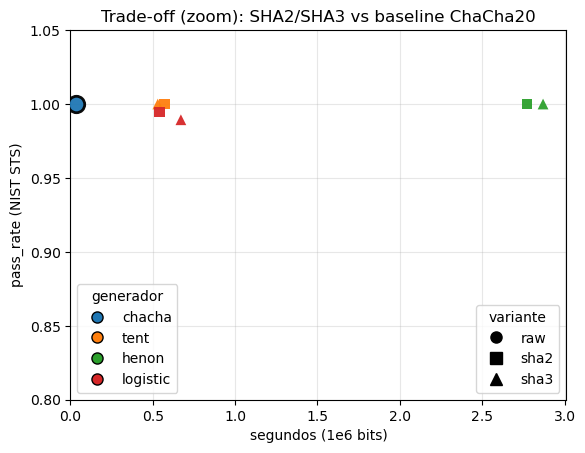

,generator,variant,seconds,pass_rate
0,chacha,raw,0.033031,1.000000
1,tent,sha3,0.530429,1.000000
2,tent,sha2,0.569364,1.000000
3,henon,sha2,2.772850,1.000000
4,henon,sha3,2.869796,1.000000
5,logistic,sha2,0.539028,0.994681
6,logistic,sha3,0.670711,0.989362


In [12]:
df_zoom = plot_tradeoff_zoom_hashes(
    df_eval,
    min_y=0.80,
    title="Trade-off (zoom): SHA2/SHA3 vs baseline ChaCha20",
)

df_zoom[["generator", "variant", "seconds", "pass_rate"]]


### Trade-off entre calidad estadística y coste computacional

La gráfica muestra el compromiso entre calidad estadística (tasa de aceptación NIST STS) y coste computacional (tiempo necesario para generar 10⁶ bits) para las variantes basadas en SHA-2 y SHA-3 de los distintos generadores caóticos, comparadas con la implementación de referencia ChaCha20.

En términos de calidad, todas las configuraciones basadas en SHA-2 y SHA-3 alcanzan tasas de aceptación cercanas o iguales al 100 %, lo que confirma que la aplicación de funciones hash criptográficas elimina eficazmente las dependencias deterministas presentes en la salida de los mapas caóticos. En este aspecto, su comportamiento es indistinguible del generador criptográfico ChaCha20, que actúa como línea base.

No obstante, las diferencias son claras en el eje de coste. ChaCha20 presenta el mejor rendimiento computacional, generando 10⁶ bits en aproximadamente 0.03 segundos. Las variantes caóticas con postprocesado hash requieren entre 0.5 y 0.7 segundos para los mapas tent y logístico, y alrededor de 2.8 segundos para el mapa de Hénon, reflejando el mayor coste de su dinámica bidimensional.

La comparación entre SHA-2 y SHA-3 no muestra diferencias significativas en calidad estadística, pero sí ligeras variaciones en tiempo de ejecución, con SHA-2 resultando marginalmente más eficiente en la mayoría de los casos. En cualquier caso, el factor dominante en el coste es el mapa subyacente, no la función hash empleada.

En conjunto, estos resultados evidencian que el uso de mapas caóticos con postprocesado criptográfico permite alcanzar niveles de calidad comparables a los de generadores criptográficos estándar, a costa de un mayor tiempo de generación, especialmente acusado en mapas de mayor complejidad dinámica.


## Conclusiones

En este trabajo se ha evaluado el uso de mapas caóticos discretizados como generadores pseudoaleatorios, analizando tanto su calidad estadística mediante el conjunto de pruebas NIST STS como su coste computacional en diferentes configuraciones. Para ello se ha construido un flujo completo de evaluación que conecta generación, análisis estadístico y benchmarking, permitiendo comparar variantes de forma coherente y trazable.

Los resultados muestran de forma consistente que las variantes sin postprocesado (**raw**) presentan tasas de aceptación muy bajas en todos los mapas analizados, confirmando que la dinámica caótica, aunque compleja, no es suficiente para garantizar aleatoriedad estadística. La aplicación del extractor de Von Neumann (**vn**) introduce mejoras apreciables (especialmente en familias relacionadas con sesgo), pero no logra alcanzar niveles de aceptación aceptables de manera global, lo que limita su utilidad como solución independiente.

En contraste, las variantes basadas en funciones hash criptográficas (**SHA-2** y **SHA-3**) alcanzan tasas de aceptación prácticamente perfectas en todos los mapas y familias de pruebas consideradas. Esto evidencia que el postprocesado criptográfico es un mecanismo eficaz para eliminar correlaciones residuales y transformar una fuente determinista caótica en una secuencia estadísticamente indistinguible de una fuente aleatoria ideal según NIST STS. En el caso particular del mapa logístico, donde se observan leves degradaciones frente al 100% global, el análisis fino por familias y por tests concretos permite localizar el origen de esas diferencias y evitar interpretaciones simplistas basadas sólo en la métrica global.

El análisis por **familias de tests** ha sido esencial para interpretar los fallos más allá del *pass rate* global, identificando qué propiedades estadísticas quedan comprometidas en cada configuración. En general, los defectos de raw y vn se concentran en familias asociadas a dependencias temporales, caminatas aleatorias y plantillas, mientras que los postprocesados criptográficos superan sistemáticamente todas las familias, reforzando la idea de que el mapa subyacente aporta complejidad pero el “salto” a calidad estadística robusta lo aporta el extractor.

Desde el punto de vista del rendimiento, el benchmarking revela un compromiso claro entre calidad y coste computacional. **ChaCha20** se mantiene como la opción más eficiente, ofreciendo máxima calidad estadística con un tiempo de generación significativamente inferior. Las variantes caóticas con postprocesado hash presentan un sobrecoste computacional dependiente del mapa utilizado, especialmente acusado en el caso del mapa de Hénon debido a su dinámica bidimensional. En la comparación SHA-2 vs SHA-3 no se observan diferencias relevantes en calidad estadística, y las variaciones en tiempo son secundarias frente al coste impuesto por el mapa.

En conjunto, este trabajo confirma que los mapas caóticos, por sí solos, no constituyen PRNG fiables, pero pueden emplearse como fuentes deterministas complejas cuando se combinan con técnicas de postprocesado criptográfico. No obstante, desde una perspectiva práctica orientada a eficiencia, los generadores criptográficos estándar continúan ofreciendo la mejor relación calidad–rendimiento, mientras que los enfoques caóticos resultan especialmente interesantes desde un punto de vista experimental y como objeto de estudio.

Finalmente, un aporte importante de este trabajo es la **reproducibilidad del pipeline**. La evaluación se ha estructurado como un flujo automatizable de “carga, parseo, tabla unificada, visualización,  benchmarking”, donde los resultados se incorporan directamente desde la estructura de carpetas de NIST STS (`finalAnalysisReport.txt`) a un formato tabular común. Esto permite que nuevas ejecuciones o nuevas configuraciones (`experiments_*`) se integren sin modificar el esquema general, manteniendo comparabilidad entre variantes y facilitando auditoría de resultados. Además, la abstracción por familias aporta una capa interpretativa estable incluso cuando existen tests con múltiples instancias o cuando el conjunto de pruebas crece.

Por tanto, los resultados y las interpretaciones presentadas no sólo cierran las conclusiones de este estudio, sino que sirven como **base metodológica** para trabajos futuros: explorar otros mapas, discretizaciones o parámetros, incorporar extractores adicionales, variar tamaños de muestra o añadir nuevas baselines criptográficas, todo ello conservando un marco reproducible que favorece la continuidad del análisis y la trazabilidad de las conclusiones.
